## Fazit

Die Analyse zeigt, wie Python und Pandas zur Untersuchung von Verkaufsdaten eingesetzt werden können.

Durch die Datenbereinigung, die Berechnung wichtiger Kennzahlen und die Visualisierung der Ergebnisse konnten Unterschiede zwischen Produkten, Regionen und Monaten sichtbar gemacht werden.

Das Projekt zeigt einen einfachen praktischen Anwendungsfall der Datenanalyse mit Python.

## Ergebnisse

Die Analyse zeigt Unterschiede beim Umsatz zwischen den verschiedenen Produkten und Regionen.

Das Produkt mit dem höchsten Umsatz ist das Produkt, das in der Produktanalyse an erster Stelle steht.

Auch zwischen den Regionen gibt es Unterschiede beim Umsatz. Die umsatzstärkste Region wurde anhand der berechneten Umsätze identifiziert.

Die monatliche Analyse zeigt außerdem, wie sich der Umsatz im Laufe des Jahres entwickelt.
<!--  -->

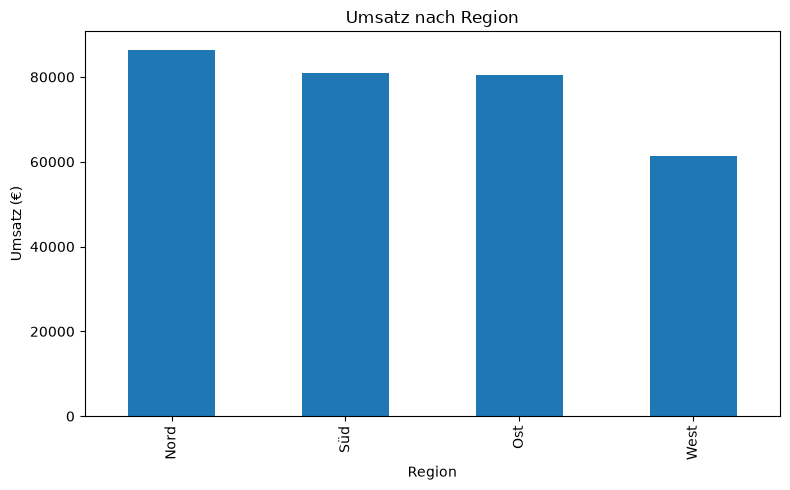

In [32]:
plt.figure(figsize=(8, 5))

umsatz_region.plot(kind="bar")

plt.title("Umsatz nach Region")
plt.xlabel("Region")
plt.ylabel("Umsatz (€)")

plt.tight_layout()
plt.savefig("../images/umsatz_nach_region.png")
plt.show()

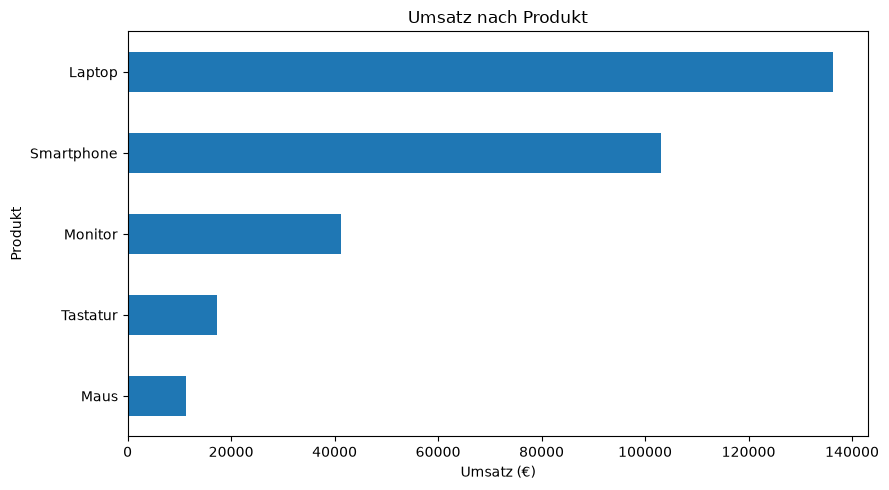

In [33]:
plt.figure(figsize=(9, 5))

umsatz_produkt.sort_values().plot(kind="barh")

plt.title("Umsatz nach Produkt")
plt.xlabel("Umsatz (€)")
plt.ylabel("Produkt")

plt.tight_layout()
plt.savefig("../images/umsatz_nach_produkt.png")
plt.show()


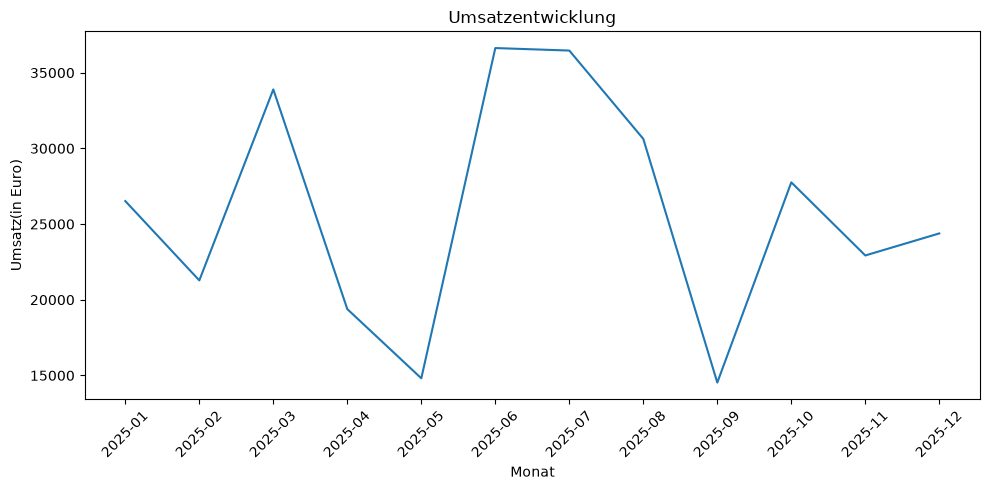

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(umsatz_monat.index.astype(str), umsatz_monat.values)

plt.title("Umsatzentwicklung")
plt.xlabel("Monat")
plt.ylabel("Umsatz(in Euro)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/umsatzentwicklung.png")
plt.show()

In [35]:
df["Monat"] = df["Datum"].dt.to_period("M")
umsatz_monat = df.groupby("Monat")["Umsatz"].sum()
umsatz_monat

Monat
2025-01    26519.80
2025-02    21277.94
2025-03    33895.74
2025-04    19381.53
2025-05    14810.91
2025-06    36628.98
2025-07    36463.78
2025-08    30627.46
2025-09    14528.58
2025-10    27756.81
2025-11    22925.65
2025-12    24382.65
Freq: M, Name: Umsatz, dtype: float64

In [36]:
beste_region = umsatz_region.idxmax()
print("Die Region mit dem höchsten Umsatz ist:", beste_region)

Die Region mit dem höchsten Umsatz ist: Nord


In [37]:
umsatz_region = (df.groupby("Region")["Umsatz"].sum().sort_values(ascending=False))
umsatz_region

Region
Nord    86446.21
Süd     80862.83
Ost     80407.21
West    61483.58
Name: Umsatz, dtype: float64

## Umsatz nach Region
Ansschließend zird der Umsatz der verschiedenen Regionen miteinander verglichen

In [23]:
bestes_produkt = umsatz_produkt.idxmax()

print("Das Produkt mit dem höchsten Umsatz ist:", bestes_produkt)

Das Produkt mit dem höchsten Umsatz ist: Laptop


In [22]:
umsatz_produkt = (df.groupby("Produkt")["Umsatz"].sum().sort_values(ascending=False))

umsatz_produkt

Produkt
Laptop        136361.64
Smartphone    103126.54
Monitor        41154.82
Tastatur       17324.34
Maus           11232.49
Name: Umsatz, dtype: float64

## Umsatz nach Product
Nun wird untersucht, welche Produkte den höchsten Umsatz erzielen.

In [21]:
df.describe

<bound method NDFrame.describe of          Datum     Produkt   Kategorie Region  Menge   Preis   Umsatz
0   2025-02-02    Tastatur     Zubehör    Süd      8   46.42   371.36
1   2025-11-10     Monitor  Elektronik   West      1  239.61   239.61
2   2025-09-19    Tastatur     Zubehör   Nord     13   44.07   572.91
3   2025-06-14      Laptop  Elektronik    Ost      5  893.90  4469.50
4   2025-07-19  Smartphone  Elektronik   Nord      1  483.71   483.71
..         ...         ...         ...    ...    ...     ...      ...
235 2025-08-06     Monitor  Elektronik   West      5  212.27  1061.35
236 2025-01-19  Smartphone  Elektronik   Nord      6  499.50  2997.00
237 2025-11-15    Tastatur     Zubehör    Ost     10   44.25   442.50
238 2025-10-02    Tastatur     Zubehör    Ost     12   46.86   562.32
239 2025-07-26    Tastatur     Zubehör    Süd     15   45.10   676.50

[240 rows x 7 columns]>

In [20]:
durchschnittpreis = df["Preis"].mean()

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [19]:
gesamtmenge = df["Menge"].sum()

print("Gesamtmenge:", gesamtmenge)

Gesamtmenge: 1374


In [18]:
gesamtumsatz = df["Umsatz"].sum()

print("Gesamtumsatz:", round(gesamtumsatz, 2), "€")

Gesamtumsatz: 309199.83 €


In [17]:
gesamtumsatz = df["Umsatz"].sum()

In [16]:
df["Umsatz"] = df["Menge"] * df["Preis"]

print(df.columns)

Index(['Datum', 'Produkt', 'Kategorie', 'Region', 'Menge', 'Preis', 'Umsatz'], dtype='str')


In [15]:
df["Datum"] = pd.to_datetime(df["Datum"])

In [14]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(2)

In [12]:
df["Preis"] = df.groupby("Produkt")["Preis"].transform(lambda x: x.fillna(x.median()))

In [11]:
 df.isnull().sum()

Datum        0
Produkt      0
Kategorie    0
Region       0
Menge        0
Preis        2
dtype: int64

In [10]:
print(df.columns)

Index(['Datum', 'Produkt', 'Kategorie', 'Region', 'Menge', 'Preis'], dtype='str')


In [9]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['Datum', 'Produkt', 'Kategorie', 'Region', 'Menge', 'Preis'], dtype='str')

In [7]:
df.info

<bound method DataFrame.info of           Datum     Produkt   Kategorie Region  Menge   Preis
0    2025-02-02    Tastatur     Zubehör    Süd      8   46.42
1    2025-11-10     Monitor  Elektronik   West      1  239.61
2    2025-09-19    Tastatur     Zubehör   Nord     13   44.07
3    2025-06-14      Laptop  Elektronik    Ost      5  893.90
4    2025-07-19  Smartphone  Elektronik   Nord      1  483.71
..          ...         ...         ...    ...    ...     ...
237  2025-11-15    Tastatur     Zubehör    Ost     10   44.25
238  2025-10-02    Tastatur     Zubehör    Ost     12   46.86
239  2025-07-26    Tastatur     Zubehör    Süd     15   45.10
240  2025-08-18    Tastatur     Zubehör    Süd     12   47.19
241  2025-07-07        Maus     Zubehör    Süd     11   25.56

[242 rows x 6 columns]>

In [6]:
df.shape

(242, 6)

In [5]:
df.head()

,Datum,Produkt,Kategorie,Region,Menge,Preis
0,2025-02-02,Tastatur,Zubehör,Süd,8,46.42
1,2025-11-10,Monitor,Elektronik,West,1,239.61
2,2025-09-19,Tastatur,Zubehör,Nord,13,44.07
3,2025-06-14,Laptop,Elektronik,Ost,5,893.90
4,2025-07-19,Smartphone,Elektronik,Nord,1,483.71


In [4]:
df = pd.read_csv('../data/sales_data.csv')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Datenanalyse von Verkaufsdaten mit Python

## Projektziel

In diesem Projekt werden Verkaufsdaten eines fiktiven Unternehmens
untersucht.

Ziel ist es, die Umsatzentwicklung zu analysieren und Unterschiede
zwischen Produkten und Regionen zu erkennen.

Dazu werden die Daten zunächst überprüft und bereinigt. Anschließend
werden wichtige Kennzahlen berechnet und die Ergebnisse visualisiert.
